# 03 — Salary Analysis

Salary distribution across families, seniority, and cities. NOTE: ~9.7% salary coverage — analyses are limited to postings that explicitly stated a salary range and must be interpreted with that selection bias in mind.

In [30]:
from analysis.utils import notebook_init

df = notebook_init()

Loaded 19,148 rows × 29 columns


In [31]:
from analysis import charts as _charts
from analysis.charts import horizontal_bar, box_plot, value_bar
from analysis.filters import salary_df

sdf = salary_df(df)
print(f"Rows with salary data: {len(sdf):,} ({len(sdf)/len(df)*100:.1f}%)")

df.head(3)

Rows with salary data: 404 (2.1%)


,row_id,job_url,date_posted,company_name,city,state,title,title_cleaned,job_family,job_summary,...,nice_to_have_skills,benefits,tasks,languages,benefit_categories,soft_skill_categories,description_quality,site,validation_flags,description
0,c3b86e465187,https://de.linkedin.com/jobs/view/softwareentw...,2025-11-17,HMS Analytical Software | Consulting & End-to-...,Heidelberg,Baden-Württemberg,Softwareentwickler / Data Engineer DevOps (mwd),Software Developer / Data Engineer DevOps,Data Engineer,Software Developer / Data Engineer DevOps crea...,...,"[""AWS"", ""Azure"", ""Scripting Languages""]","[""Flexible working hours"", ""Mobile Office / hy...","[""Create, extend and operate innovative, perfo...",[],"[""compensation"", ""education"", ""flexible_hours""...","[""Communication"", ""Customer Focus"", ""Teamwork""]",concatenated,linkedin,[],Unsere über 30-jährige Erfolgsgeschichte im So...
1,a85937eee245,https://de.linkedin.com/jobs/view/werkstudent-...,2025-12-17,HMS Analytical Software | Consulting & End-to-...,Heidelberg,Baden-Württemberg,"Werkstudent (mwd) Data Analytics, BI & Reporting","Working Student Data Analytics, BI & Reporting",Working Student,"Working student supporting data analytics, BI,...",...,"[""MS PowerBI""]","[""Flexible working hours"", ""Mobile Office/hybr...","[""Building and maintaining modern data pipelin...",[],"[""education"", ""flexible_hours"", ""food"", ""healt...","[""Teamwork""]",concatenated,linkedin,"[{""field"": ""contract_type"", ""rule"": ""intern_co...",Unsere über 35-jährige Erfolgsgeschichte im So...
2,afa0059eab62,https://de.linkedin.com/jobs/view/system-admin...,2026-01-16,NZR Nordwestdeutsche Zählerrevision Ing. Aug. ...,Bad Laer,Lower Saxony,System-Administrator (m/w/d),System-Administrator,System Administrator,System administrator responsible for maintaini...,...,"[""InforCom ERP""]","[""29 vacation days"", ""Flexible working hours"",...","[""Ensuring smooth IT operations across entire ...",[],"[""education"", ""flexible_hours"", ""health"", ""mob...","[""Structured Work"", ""Teamwork""]",concatenated,linkedin,"[{""field"": ""technical_skills"", ""rule"": ""skill_...",Ihre Vorteile bei NZR:Ein attraktives Gehalt i...


## Salary Distribution

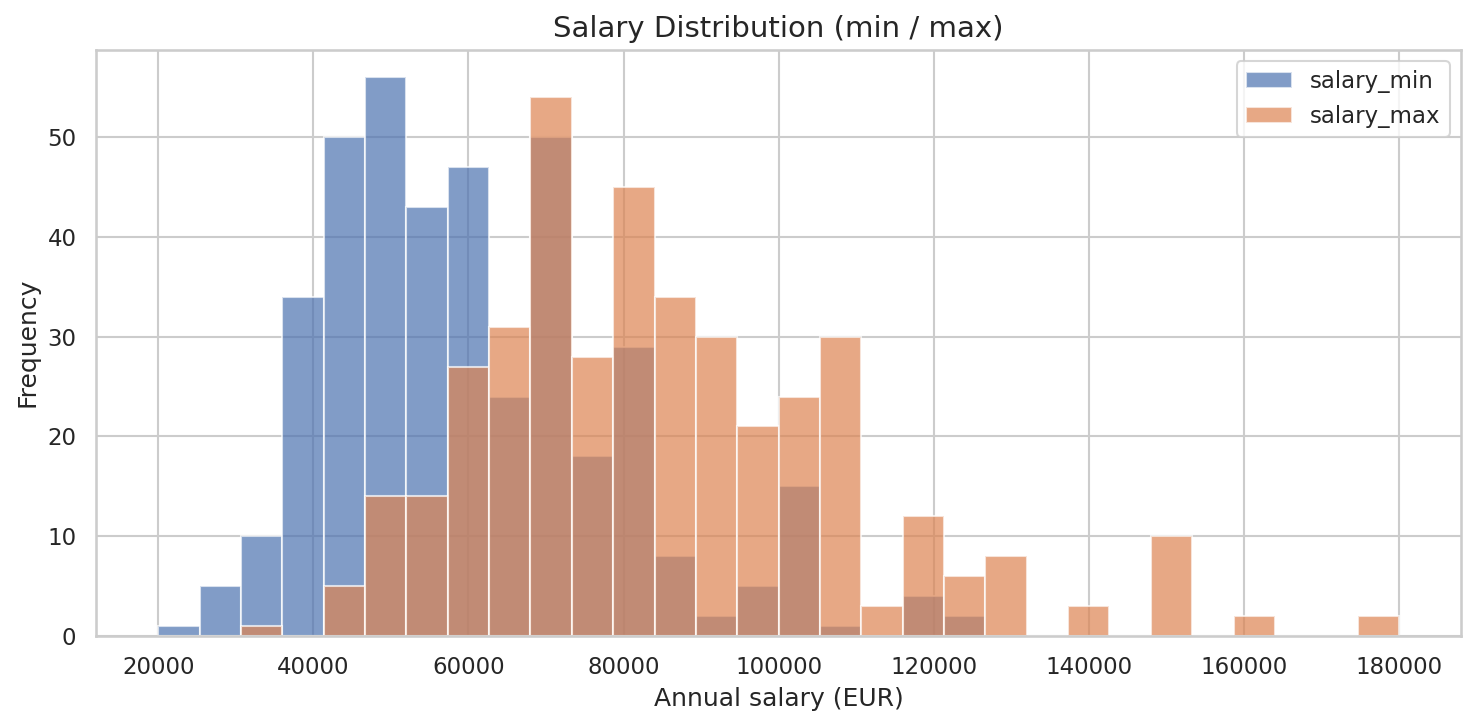

In [32]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
sdf[["salary_min", "salary_max"]].plot(kind="hist", bins=30, alpha=0.7, ax=ax)
ax.set_title("Salary Distribution (min / max)")
ax.set_xlabel("Annual salary (EUR)")
plt.tight_layout()
if _charts.FIGURES_DIR:
    fig.savefig(_charts.FIGURES_DIR / "03_salary_dist.png", dpi=150)

## Salary by Job Family

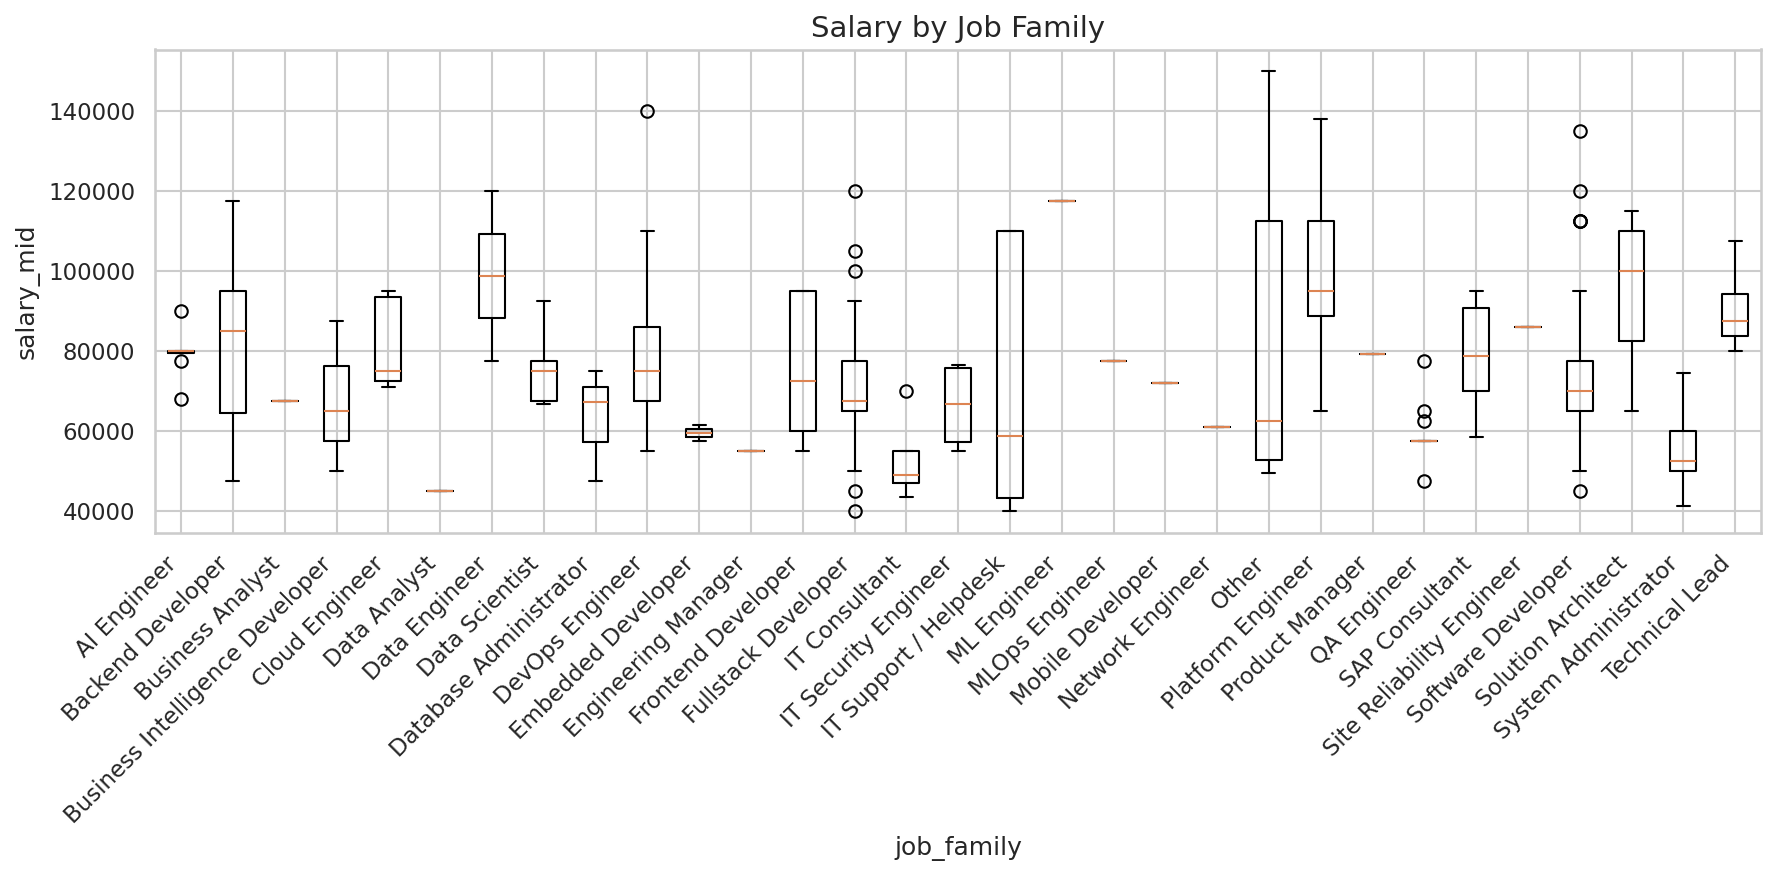

In [33]:
box_plot(sdf, "job_family", "salary_mid", "Salary by Job Family", save_as="03_salary_family.png")

## Salary by Seniority

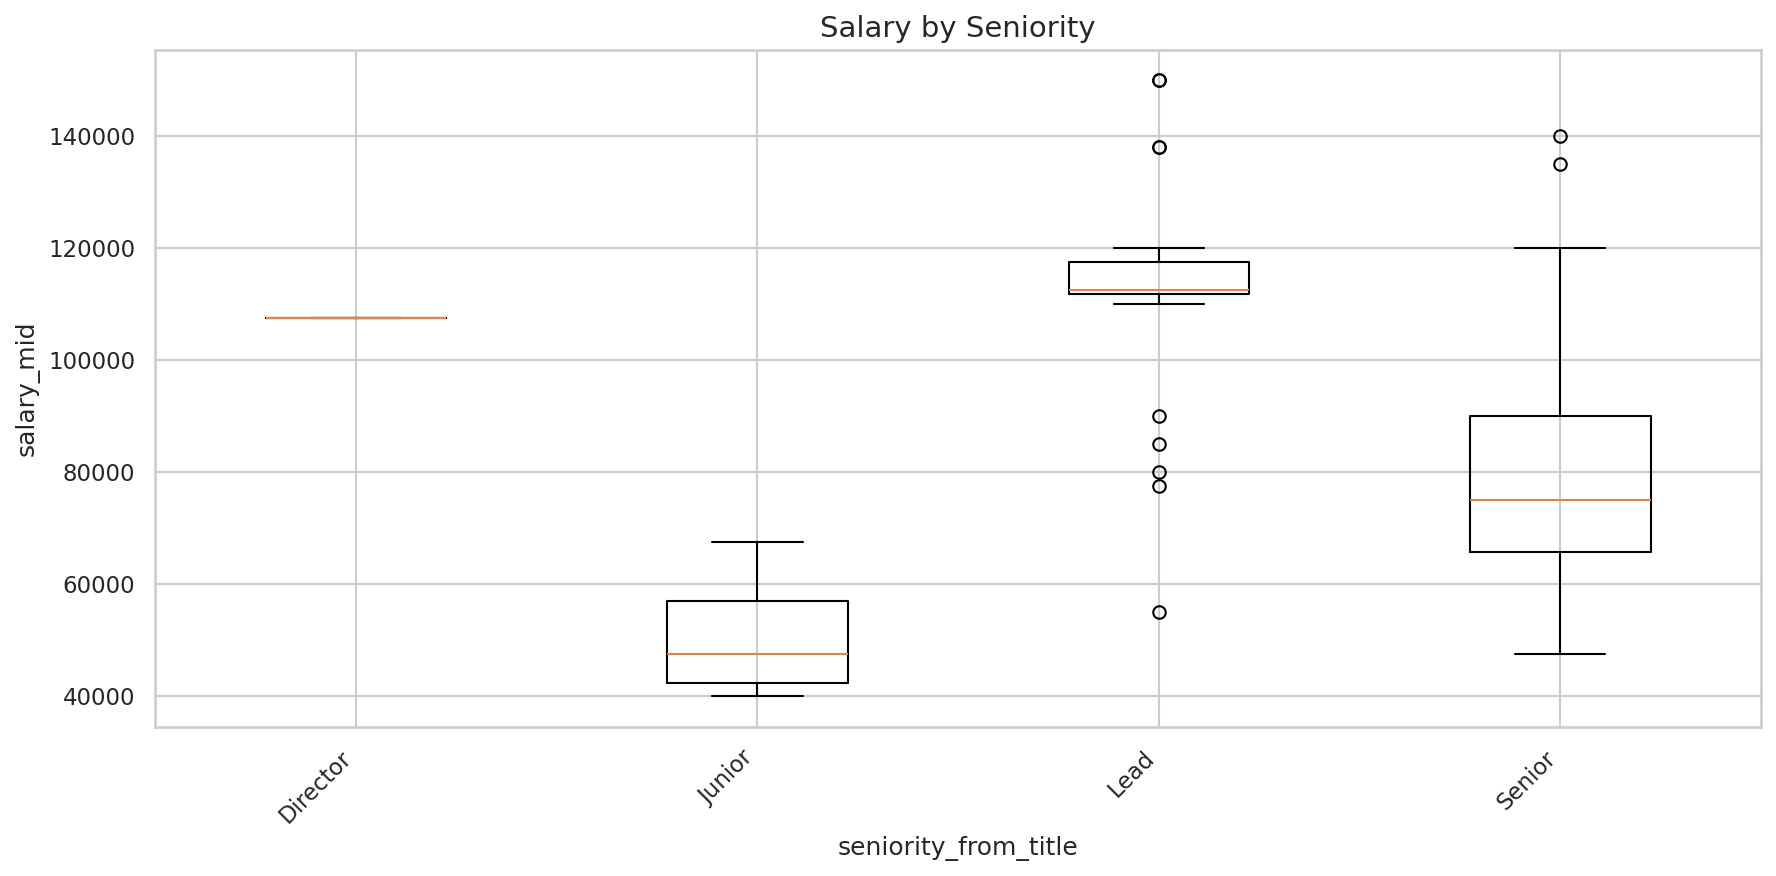

In [34]:
box_plot(sdf, "seniority_from_title", "salary_mid", "Salary by Seniority", save_as="03_salary_seniority.png")

## Salary by City

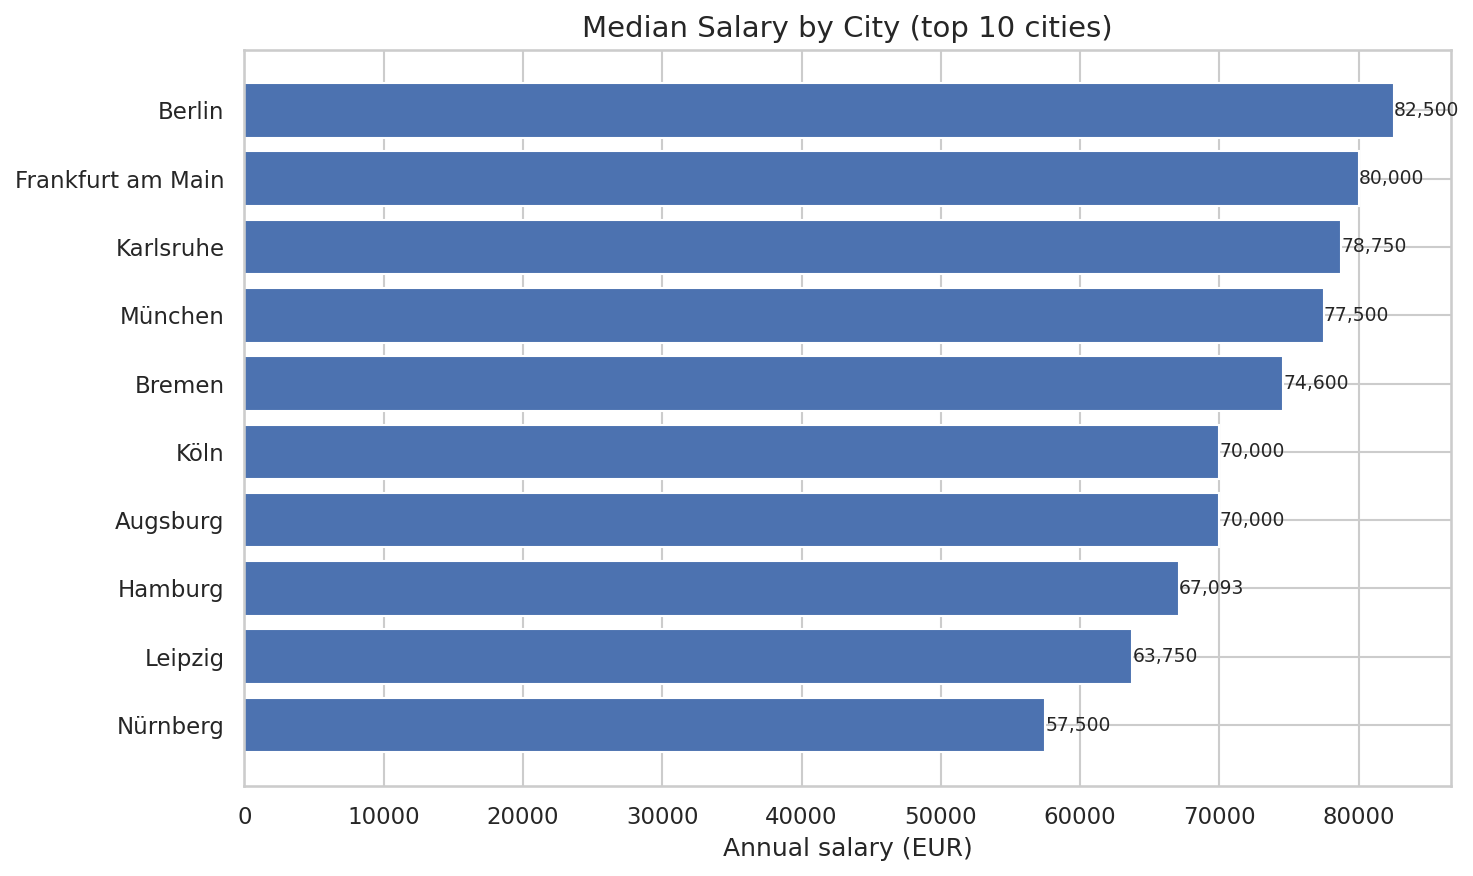

In [35]:
top_cities = sdf[sdf["city"].notna()]["city"].value_counts().head(10).index
city_median = (
    sdf[sdf["city"].isin(top_cities)]
    .groupby("city")["salary_mid"]
    .median()
    .sort_values()
)
value_bar(
    city_median.index,
    city_median.values,
    "Median Salary by City (top 10 cities)",
    xlabel="Annual salary (EUR)",
    fmt=",.0f",
    save_as="03_salary_city.png",
)

## Experience vs Salary Scatter

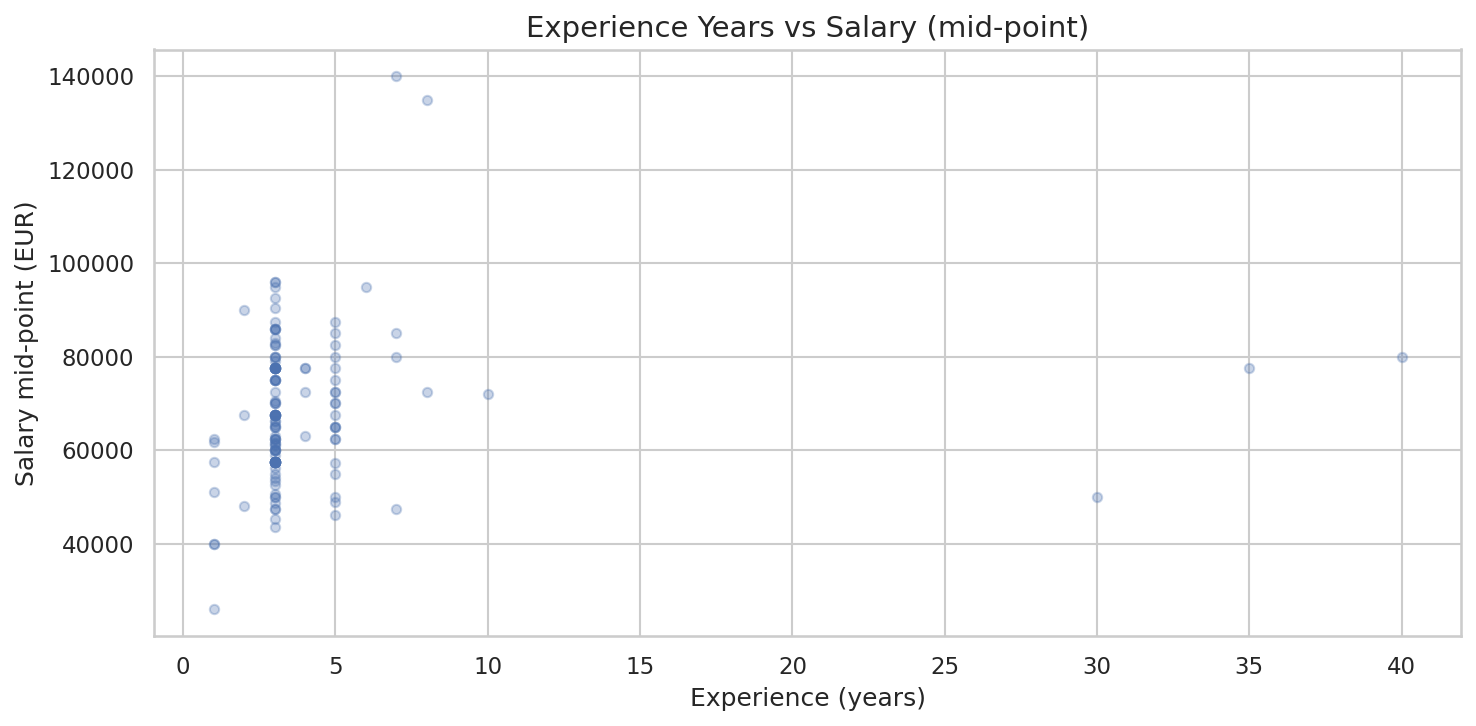

In [36]:
import matplotlib.pyplot as plt
import pandas as pd

exp_salary = sdf[sdf["experience_years"].notna()].copy()
exp_salary["experience_years"] = pd.to_numeric(exp_salary["experience_years"]).astype(int)

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(exp_salary["experience_years"], exp_salary["salary_mid"], alpha=0.3, s=20)
ax.set_title("Experience Years vs Salary (mid-point)")
ax.set_xlabel("Experience (years)")
ax.set_ylabel("Salary mid-point (EUR)")
plt.tight_layout()
if _charts.FIGURES_DIR:
    fig.savefig(_charts.FIGURES_DIR / "03_exp_salary_scatter.png", dpi=150)
plt.show()
plt.close(fig)